# Molecular Binding using VQE: H2

This notebook follows the project goal of running a real VQE simulation for H2 and comparing it with an original first-principles reference curve.

Workflow used here:
- Reference curve: PySCF FCI energies (WSL, project .wsl_venv)
- Simulator curve: Qiskit VQE on the same Hamiltonian
- Diagnostics printed: Hamiltonian details, ansatz circuit, estimator choices and behavior
- Visualization: PE vs bond length and absolute error vs bond length

In [1]:
import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (10, 6)
np.set_printoptions(precision=8, suppress=True)

WSL_PROJECT_DIR = "/mnt/e/QC Project/Implementation/Molecular Binding using VQE"

## 1) Environment check

This notebook runs chemistry computations inside WSL from `.wsl_venv`.

In [2]:
check_cmd = [
    'wsl',
    '-e',
    'bash',
    '-lc',
    "cd '" + WSL_PROJECT_DIR + "' && . .wsl_venv/bin/activate && python -c \"import pyscf, qiskit, qiskit_nature; print('pyscf', pyscf.__version__); print('qiskit', qiskit.__version__); print('qiskit_nature', qiskit_nature.__version__)\"",
]

check = subprocess.run(check_cmd, capture_output=True, text=True, check=False)
print(check.stdout if check.stdout else check.stderr)
if check.returncode != 0:
    raise RuntimeError('WSL chemistry environment check failed.')

pyscf 2.13.0
qiskit 2.4.1
qiskit_nature 0.7.2



## 2) Single-point VQE diagnostics (Hamiltonian, ansatz, estimator)

This step prints details at one bond length (0.74 Angstrom):
- fermionic and qubit Hamiltonian summary
- ansatz circuit text diagram
- estimator options and the estimator used for VQE

In [6]:
def run_wsl_python(script_text: str) -> subprocess.CompletedProcess:
    temp_script = Path('_wsl_temp_vqe_notebook.py')
    temp_script.write_text(script_text, encoding='utf-8')

    cmd = [
        'wsl',
        '-e',
        'bash',
        '-lc',
        "cd '" + WSL_PROJECT_DIR + "' && . .wsl_venv/bin/activate && python _wsl_temp_vqe_notebook.py",
    ]

    try:
        return subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            encoding='utf-8',
            errors='replace',
            check=False,
        )
    finally:
        if temp_script.exists():
            temp_script.unlink()


single_point_script = r'''
import json

from qiskit.primitives import StatevectorEstimator
from qiskit_aer.primitives import EstimatorV2
from qiskit_algorithms.minimum_eigensolvers import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.units import DistanceUnit

R = 0.74
atom = f"H 0 0 0; H 0 0 {R}"
driver = PySCFDriver(atom=atom, basis="sto3g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
problem = driver.run()

mapper = JordanWignerMapper()
second_q_op = problem.hamiltonian.second_q_op()
qubit_op = mapper.map(second_q_op)

init_state = HartreeFock(problem.num_spatial_orbitals, problem.num_particles, mapper)
ansatz = UCCSD(problem.num_spatial_orbitals, problem.num_particles, mapper, initial_state=init_state)

estimator_exact = StatevectorEstimator()
estimator_shots = EstimatorV2(options={"run_options": {"shots": 2000}})

print("=== Estimator options ===")
print("Exact estimator      :", type(estimator_exact).__name__)
print("Shot-based estimator :", type(estimator_shots).__name__, estimator_shots.options.run_options)
print("Working estimator for VQE run: StatevectorEstimator (deterministic baseline)")

print("\n=== Hamiltonian summary ===")
print("Fermionic terms:", len(second_q_op))
print("Qubit Hamiltonian qubits:", qubit_op.num_qubits)
print("Qubit Hamiltonian terms:", len(qubit_op))
print("First 10 Pauli terms:")
for idx, (p, c) in enumerate(qubit_op.to_list()[:10], start=1):
    print(f"  {idx:2d}. {p:>8s}  coeff={c}")

print("\n=== Ansatz circuit ===")
print("Ansatz class:", type(ansatz).__name__)
print("Num qubits:", ansatz.num_qubits)
print("Num parameters:", ansatz.num_parameters)
print(ansatz.decompose().draw(output="text"))

vqe = VQE(estimator_exact, ansatz, SLSQP(maxiter=150))
result = vqe.compute_minimum_eigenvalue(qubit_op)
interpreted = problem.interpret(result)

payload = {
    "R": R,
    "vqe_total_energy": float(interpreted.total_energies[0].real),
    "num_qubits": int(qubit_op.num_qubits),
    "num_qubit_terms": int(len(qubit_op)),
}
print("JSON_RESULT:" + json.dumps(payload))
'''

single_point = run_wsl_python(single_point_script)
print(single_point.stdout if single_point.stdout else single_point.stderr)

if single_point.returncode != 0:
    raise RuntimeError('Single-point diagnostic run failed.')

json_line = [line for line in single_point.stdout.splitlines() if line.startswith('JSON_RESULT:')][-1]
single_point_result = json.loads(json_line.replace('JSON_RESULT:', '', 1))
print('Parsed summary:', single_point_result)

=== Estimator options ===
Exact estimator      : StatevectorEstimator
Shot-based estimator : EstimatorV2 {'shots': 2000}
Working estimator for VQE run: StatevectorEstimator (deterministic baseline)

=== Hamiltonian summary ===
Fermionic terms: 36
Qubit Hamiltonian qubits: 4
Qubit Hamiltonian terms: 15
First 10 Pauli terms:
   1.     IIII  coeff=(-0.8121706072487127+0j)
   2.     IIIZ  coeff=(0.17141282644776923+0j)
   3.     IIZI  coeff=(-0.22343153690813425+0j)
   4.     IIZZ  coeff=(0.12062523483390411+0j)
   5.     IZII  coeff=(0.17141282644776923+0j)
   6.     IZIZ  coeff=(0.16868898170361207+0j)
   7.     ZIII  coeff=(-0.22343153690813425+0j)
   8.     ZIIZ  coeff=(0.16592785033770335+0j)
   9.     YYYY  coeff=(0.04530261550379926+0j)
  10.     XXYY  coeff=(0.04530261550379926+0j)

=== Ansatz circuit ===
Ansatz class: UCCSD
Num qubits: 4
Num parameters: 3
     ┌───┐┌───────────────────────────────┐┌───────────────────────────────┐»
q_0: ┤ X ├┤0                              ├┤0    

## 3) Full PE curve: reference vs simulator

We now run both curves over the same bond-length grid and compare them directly.

Mode switch (edit in the next code cell):
- `VQE_MODE = "exact"` -> deterministic statevector estimator (curves are usually almost identical)
- `VQE_MODE = "shots"` -> finite-shot estimator (small visible deviations are expected)
- `VQE_SHOTS` controls sampling noise when using shot mode

In [10]:
bond_grid = np.array(sorted(set(np.round(np.linspace(0.4, 1.6, 13), 2).tolist() + [0.74])), dtype=float)
bond_grid_json = json.dumps([float(x) for x in bond_grid])

# Switch mode here: "exact" or "shots"
VQE_MODE = "shots"
VQE_SHOTS = 2000
VQE_MAXITER = 120

curve_script = f'''
import json

from pyscf import fci, gto, scf
from qiskit.primitives import StatevectorEstimator
from qiskit_aer.primitives import EstimatorV2
from qiskit_algorithms.minimum_eigensolvers import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.units import DistanceUnit

MODE = "{VQE_MODE}"
SHOTS = {VQE_SHOTS}
MAXITER = {VQE_MAXITER}

def pyscf_reference_energy(r_angstrom: float) -> float:
    atom = f"H 0 0 0; H 0 0 {{r_angstrom}}"
    mol = gto.M(atom=atom, basis="sto3g", unit="Angstrom", spin=0, charge=0, verbose=0)
    mf = scf.RHF(mol)
    mf.kernel()
    cisolver = fci.FCI(mf)
    e_fci, _ = cisolver.kernel()
    return float(e_fci)

def qiskit_vqe_energy(r_angstrom: float) -> float:
    atom = f"H 0 0 0; H 0 0 {{r_angstrom}}"
    driver = PySCFDriver(atom=atom, basis="sto3g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()

    mapper = JordanWignerMapper()
    qubit_op = mapper.map(problem.hamiltonian.second_q_op())

    init_state = HartreeFock(problem.num_spatial_orbitals, problem.num_particles, mapper)
    ansatz = UCCSD(problem.num_spatial_orbitals, problem.num_particles, mapper, initial_state=init_state)

    if MODE == "exact":
        estimator = StatevectorEstimator()
        vqe_ansatz = ansatz
    elif MODE == "shots":
        estimator = EstimatorV2(options={{"run_options": {{"shots": SHOTS, "seed_simulator": 7}}}})
        # Decompose multiple times to fully convert PauliEvolution gates to basis gates for Aer
        vqe_ansatz = ansatz.decompose()
        vqe_ansatz = vqe_ansatz.decompose()
        vqe_ansatz = vqe_ansatz.decompose()
    else:
        raise ValueError(f"Unknown MODE: {{MODE}}. Use 'exact' or 'shots'.")

    vqe = VQE(estimator, vqe_ansatz, SLSQP(maxiter=MAXITER))
    result = vqe.compute_minimum_eigenvalue(qubit_op)
    interpreted = problem.interpret(result)
    return float(interpreted.total_energies[0].real)

bond_lengths = {bond_grid_json}
reference_curve = []
vqe_curve = []

print(f"Running mode={{MODE}}, shots={{SHOTS if MODE == 'shots' else 'n/a'}}, maxiter={{MAXITER}}")
for r in bond_lengths:
    e_ref = pyscf_reference_energy(r)
    e_vqe = qiskit_vqe_energy(r)
    reference_curve.append(e_ref)
    vqe_curve.append(e_vqe)
    print(f"R = {{r:.2f}} A | reference = {{e_ref:.8f}} Ha | vqe = {{e_vqe:.8f}} Ha")

print("JSON_RESULT:" + json.dumps({{"bond_lengths": bond_lengths, "reference": reference_curve, "vqe": vqe_curve, "mode": MODE, "shots": SHOTS, "maxiter": MAXITER}}))
'''

curve_result = run_wsl_python(curve_script)
print(curve_result.stdout if curve_result.stdout else curve_result.stderr)

if curve_result.returncode != 0:
    raise RuntimeError('Curve calculation failed.')

curve_json_line = [line for line in curve_result.stdout.splitlines() if line.startswith('JSON_RESULT:')][-1]
curve_payload = json.loads(curve_json_line.replace('JSON_RESULT:', '', 1))

bond_lengths = np.array(curve_payload['bond_lengths'], dtype=float)
reference_energies = np.array(curve_payload['reference'], dtype=float)
vqe_energies = np.array(curve_payload['vqe'], dtype=float)

print(f"Selected mode: {curve_payload['mode']} | shots: {curve_payload['shots']} | maxiter: {curve_payload['maxiter']}")

Running mode=shots, shots=2000, maxiter=120
R = 0.40 A | reference = -0.91414970 Ha | vqe = -0.91414955 Ha
R = 0.50 A | reference = -1.05515979 Ha | vqe = -1.05515978 Ha
R = 0.60 A | reference = -1.11628601 Ha | vqe = -1.11628599 Ha
R = 0.70 A | reference = -1.13618945 Ha | vqe = -1.13618919 Ha
R = 0.74 A | reference = -1.13728383 Ha | vqe = -1.13728378 Ha
R = 0.80 A | reference = -1.13414767 Ha | vqe = -1.13414726 Ha
R = 0.90 A | reference = -1.12056028 Ha | vqe = -1.12056024 Ha
R = 1.00 A | reference = -1.10115033 Ha | vqe = -1.10114970 Ha
R = 1.10 A | reference = -1.07919294 Ha | vqe = -1.07919294 Ha
R = 1.20 A | reference = -1.05674075 Ha | vqe = -1.05674073 Ha
R = 1.30 A | reference = -1.03518627 Ha | vqe = -1.03518603 Ha
R = 1.40 A | reference = -1.01546825 Ha | vqe = -1.01546825 Ha
R = 1.50 A | reference = -0.99814935 Ha | vqe = -0.99814933 Ha
R = 1.60 A | reference = -0.98347273 Ha | vqe = -0.98347271 Ha
JSON_RESULT:{"bond_lengths": [0.4, 0.5, 0.6, 0.7, 0.74, 0.8, 0.9, 1.0, 1.1

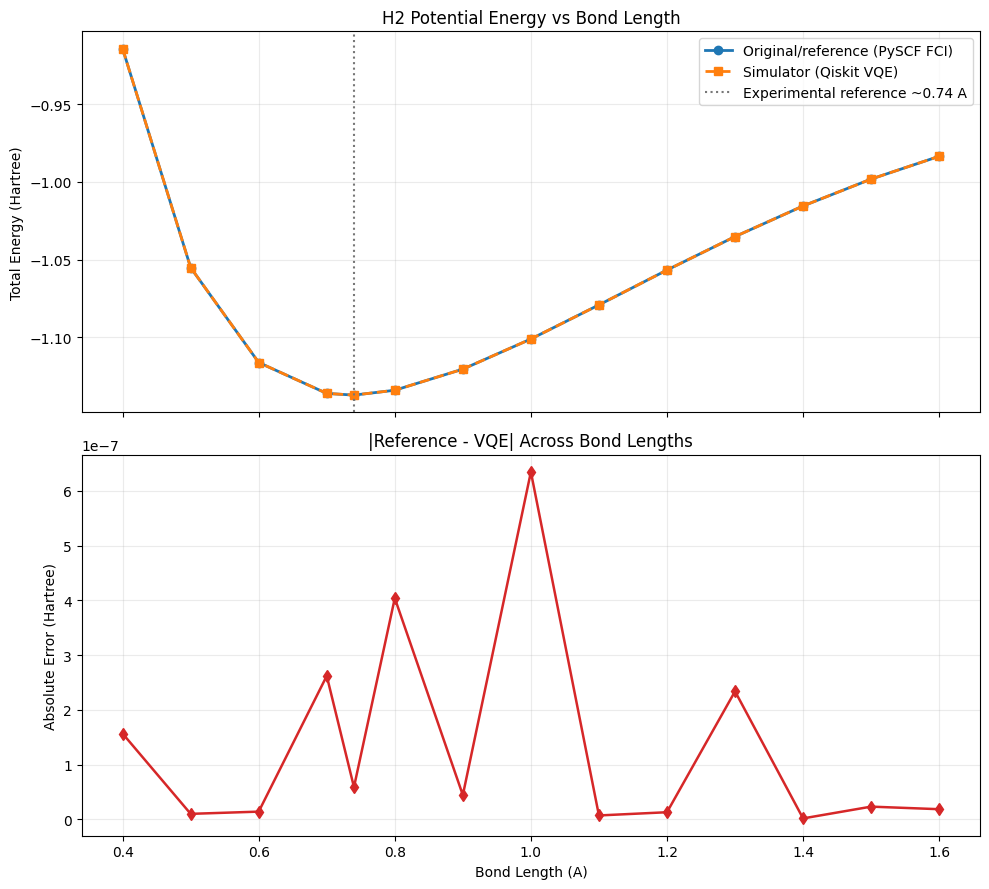

Reference minimum: R = 0.74 A, E = -1.13728383 Ha
VQE minimum      : R = 0.74 A, E = -1.13728378 Ha
Max absolute error: 6.348e-07 Ha
Mean absolute error: 1.345e-07 Ha


In [11]:
abs_error = np.abs(reference_energies - vqe_energies)
ref_min_idx = int(np.argmin(reference_energies))
vqe_min_idx = int(np.argmin(vqe_energies))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

ax1.plot(bond_lengths, reference_energies, marker='o', linewidth=2.0, label='Original/reference (PySCF FCI)')
ax1.plot(bond_lengths, vqe_energies, marker='s', linestyle='--', linewidth=2.0, label='Simulator (Qiskit VQE)')
ax1.axvline(0.74, color='#777777', linestyle=':', linewidth=1.5, label='Experimental reference ~0.74 A')
ax1.set_ylabel('Total Energy (Hartree)')
ax1.set_title('H2 Potential Energy vs Bond Length')
ax1.grid(alpha=0.25)
ax1.legend()

ax2.plot(bond_lengths, abs_error, marker='d', color='#d62728', linewidth=1.8)
ax2.set_xlabel('Bond Length (A)')
ax2.set_ylabel('Absolute Error (Hartree)')
ax2.set_title('|Reference - VQE| Across Bond Lengths')
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f'Reference minimum: R = {bond_lengths[ref_min_idx]:.2f} A, E = {reference_energies[ref_min_idx]:.8f} Ha')
print(f'VQE minimum      : R = {bond_lengths[vqe_min_idx]:.2f} A, E = {vqe_energies[vqe_min_idx]:.8f} Ha')
print(f'Max absolute error: {abs_error.max():.3e} Ha')
print(f'Mean absolute error: {abs_error.mean():.3e} Ha')

## 4) Notes

- Yes, this is a real VQE simulation, not only an analytic fit.
- Hamiltonian mapping and ansatz construction are printed in the diagnostics section.
- StatevectorEstimator is used for the reported VQE curve to provide deterministic convergence; shot-based EstimatorV2 options are printed as well.
- The PE comparison is generated in this same notebook (single ipynb file).